In [21]:
from ader_dg_transport.ader_dg_1D import advection_ader_standard_1D
import numpy as np
import importlib
from matplotlib import pyplot as plt

## Create 1D ADER DG advection solver

Run and observe growth.

Text(0, 0.5, 'u')

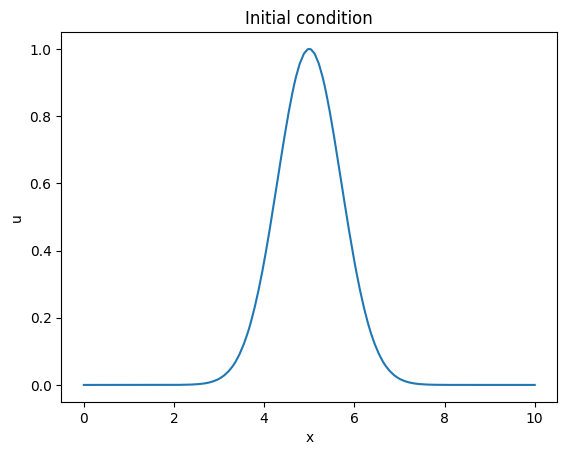

In [260]:
importlib.reload(advection_ader_standard_1D)

xlim = 10
nx = 30
poly_order = 5
c = 1.0
dx = xlim / nx
dt = 0.7 * dx / ((2 * poly_order + 1) * c)

solver = advection_ader_standard_1D.AdvectionADERDG1D(xlim, nx, poly_order, dt, c)
xs = solver.xs[:, 0, :]
solver.u[:]= np.exp(-(xs - 5)**2)

E0 = solver.norm()
plt.title('Initial condition')
plt.plot(xs.ravel(), solver.u.ravel())
plt.xlabel('x')
plt.ylabel('u')

2.1045520881557422e-08


Text(0, 0.5, 'u')

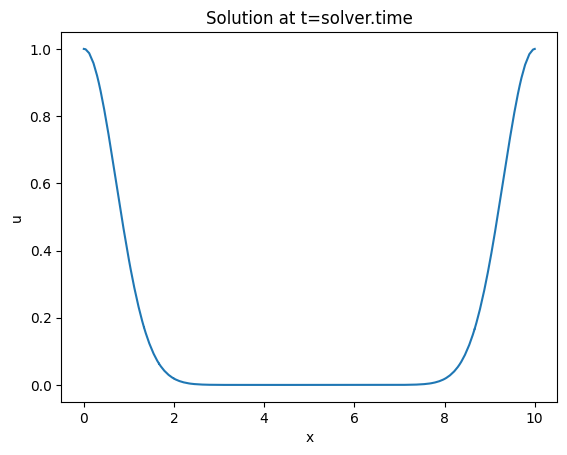

In [261]:
norms = [E0]
while solver.time < 10:
    solver.time_step()
    norms.append(solver.norm())
    
norms = np.array(norms)
E1 = norms[-1]
print(E1 - E0)

plt.title(f'Solution at t=solver.time')
plt.plot(xs.ravel(), solver.u.ravel())
plt.xlabel('x')
plt.ylabel('u')

Text(0, 0.5, 'Relative energy error')

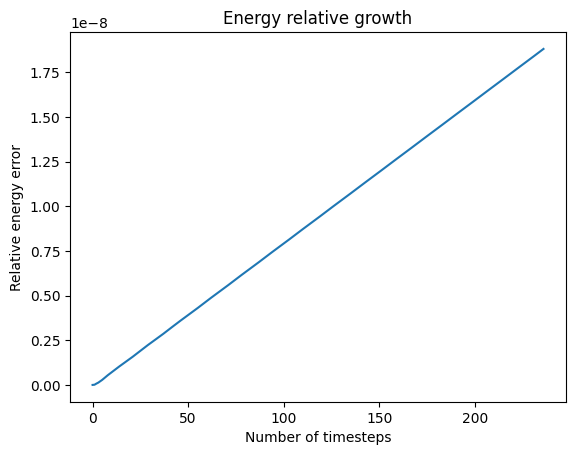

In [262]:
plt.title('Energy relative growth')
plt.plot((norms - norms[0]) / norms[0])
plt.xlabel('Number of timesteps')
plt.ylabel('Relative energy error')

In [263]:
print('Max observed amplification:', ((norms[1:] / norms[:-1]) - 1).max())

Max observed amplification: 9.016698498953701e-11


## Analyze linear operator

Here we find the eigenvalues and singular values. While the eigenvalues suggest the method is stable, the SVD shows that it is not. The largest singular value is 

In [264]:
rows = []
arr = np.zeros(solver.u.size)
for i in range(solver.u.size):
    arr[:] = 0.0
    arr[i] = 1.0
    solver.u[:] = arr.reshape(solver.u.shape)
    solver.time_step()

    rows.append(solver.u.ravel().copy())

A = np.array(rows).T.copy()

weights = (np.ones(solver.nx)[:, None] * solver.weights_x).ravel() * 0.5 * solver.dx

In [265]:
arr = np.random.random(solver.u.shape)

solver.u[:] = arr
solver.time_step()

assert np.allclose(solver.u.ravel(), A @ arr.ravel()) 
assert np.allclose(solver.integrate(arr), (arr.ravel() * weights).sum())

In [266]:
W_half = np.diag(weights ** 0.5)
W_half_inv = np.diag(weights ** -0.5)

In [267]:
print('Max abs eigenvalue = 1 +', abs(np.linalg.eigvals(A)).max() - 1)
print('Max singular value = 1 +', abs(np.linalg.svd(W_half @ A @ W_half_inv, compute_uv=False)).max() - 1)

Max abs eigenvalue = 1 + 7.532822046218968e-05
Max singular value = 1 + 0.6631993664545994


Text(0, 0.5, 'u')

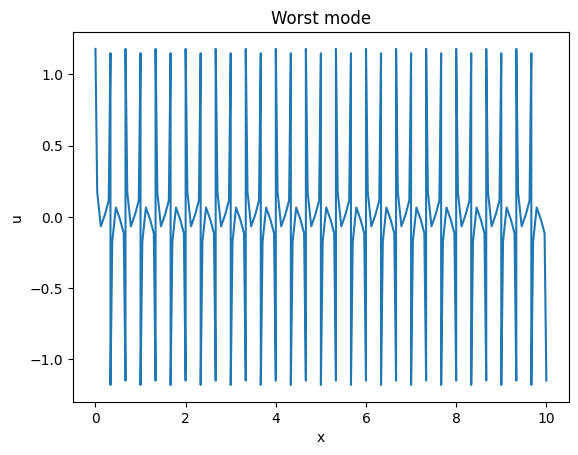

In [268]:
U, S, V = np.linalg.svd(W_half @ A @ W_half_inv)
bad_mode = W_half_inv @ V[0, :]

solver.time = 0
solver.u[:] = bad_mode.reshape(solver.u.shape)

plt.title('Worst mode')
plt.plot(xs.ravel(), solver.u.ravel())
plt.xlabel('x')
plt.ylabel('u')

-1.003786721593171


Text(0, 0.5, 'u')

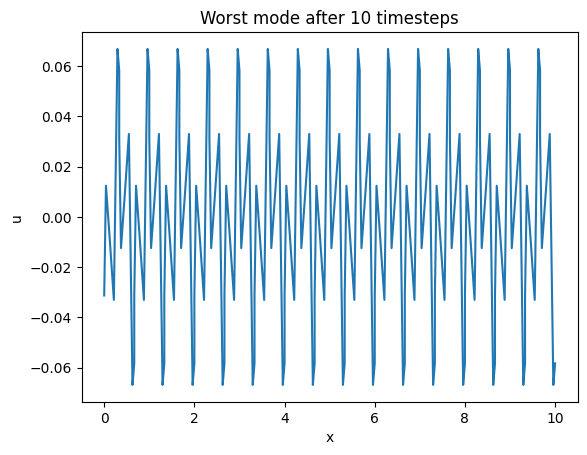

In [269]:
norms = [E0]
nsteps = 10
for _ in range(nsteps):
    solver.time_step()
    norms.append(solver.norm())
    
norms = np.array(norms)
E1 = norms[-1]
print(E1 - E0)

plt.title(f'Worst mode after {nsteps} timesteps')
plt.plot(xs.ravel(), solver.u.ravel())
plt.xlabel('x')
plt.ylabel('u')

Text(0, 0.5, 'Relative energy error')

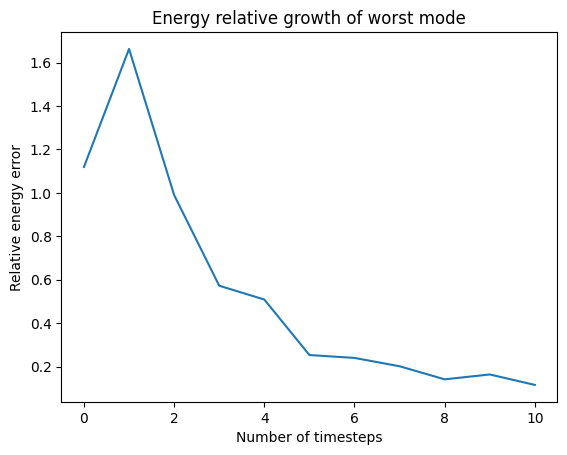

In [273]:
plt.title('Energy relative growth of worst mode')
plt.plot(norms)
plt.xlabel('Number of timesteps')
plt.ylabel('Relative energy error')

## Von Neumann Analaysis

Replicate linear analysis with Von Neumann analysis. 

In [235]:
import numpy as np
from ader_dg_transport.utils import gll, lagrange1st
from scipy.linalg import lu_factor, lu_solve
import scipy

In [236]:
def get_matrices(order):
    n = order + 1
    to_st_first = np.zeros((n * n, n))
    for i in range(n):
        to_st_first[i, i] = 1.0

    to_st_last = np.zeros((n * n, n))
    for i in range(n):
        to_st_last[-(n - i), i] = 1.0

    from_st_first = np.zeros((n, n * n))
    for i in range(n):
        from_st_first[i, i] = 1.0

    from_st_last = np.zeros((n, n * n))
    for i in range(n):
        from_st_last[i, -(n - i)] = 1.0

    I = np.eye(n)

    assert np.allclose(from_st_first @ to_st_first, I)
    assert np.allclose(from_st_last @ to_st_last, I)

    xs, w_x = gll(order, iterative=True)
    D = lagrange1st(order, xs).transpose()

    Dx = np.zeros((n, n, n, n))
    Dt = np.zeros((n, n, n, n))

    for i in range(n):
        for j in range(n):
            for k in range(n):
                val = D[i, j]
                Dx[k, i, k, j] = val
                Dt[i, k, j, k] = val

    assert np.allclose(Dt.swapaxes(0, 1).swapaxes(2, 3), Dx)
    Dx = Dx.reshape((D.size, D.size))
    Dt = Dt.reshape(Dx.shape)

    assert np.allclose(from_st_first @ Dx @ to_st_first, D)
    assert np.allclose(from_st_last @ Dx @ to_st_last, D)

    volume_integral = np.zeros((n, n, n, n))

    left_time_integral = np.zeros((n, n, n, n))  # dt when x = -1
    right_time_integral = np.zeros((n, n, n, n))  # dt when x = 1

    first_space_integral = np.zeros((n, n, n, n))  # dx when t = -1
    last_space_integral = np.zeros((n, n, n, n))  # dx when t = 1

    pick_x0_t1 = np.zeros((n, n, n, n))
    pick_x0_t1[:, 0, -1, 0] = 1.0

    right_to_left = np.zeros((n, n, n, n))
    last_to_first = np.zeros((n, n, n, n))

    for i in range(n):
        for j in range(n):
            volume_integral[i, j, i, j] = w_x[i] * w_x[j]

        left_time_integral[i, 0, i, 0] =  1 / w_x[-1]
        right_time_integral[i, -1, i, -1] = 1 / w_x[-1]

        first_space_integral[0, i, 0, i] = 1 / w_x[-1]
        last_space_integral[-1, i, -1, i] = 1 / w_x[-1]

        right_to_left[i, 0, i, -1] = 1.0
        last_to_first[0, i, -1, i] = 1.0

    volume_integral = volume_integral.reshape(Dx.shape)

    left_time_integral = left_time_integral.reshape(Dx.shape)
    right_time_integral = right_time_integral.reshape(Dx.shape)

    first_space_integral = first_space_integral.reshape(Dx.shape)
    last_space_integral = last_space_integral.reshape(Dx.shape)

    pick_x0_t1 = pick_x0_t1.reshape(Dx.shape)

    right_to_left = right_to_left.reshape(Dx.shape)
    last_to_first = last_to_first.reshape(Dx.shape)

    assert np.allclose(to_st_first @ from_st_last, last_to_first)

    assert np.allclose(left_time_integral @ right_to_left, right_to_left @ right_time_integral)
    assert np.allclose(first_space_integral @ last_to_first, last_to_first @ last_space_integral)

    return (to_st_first, to_st_last, from_st_first, from_st_last, Dx, Dt,
            volume_integral, left_time_integral, right_time_integral, first_space_integral, last_space_integral,
            pick_x0_t1, right_to_left, last_to_first
            )

In [237]:
(to_st_first, to_st_last, from_st_first, from_st_last, Dx, Dt, 
 volume_integral, left_time_integral, right_time_integral, first_space_integral
 , last_space_integral, pick_x0_t1, right_to_left, last_to_first) = get_matrices(5)

In [238]:
cfl = solver.cfl
space_shifts = np.linspace(0, 2 * np.pi, 2000) * 1.0j

M1 = Dt + cfl * Dx + first_space_integral

R1 = first_space_integral @ last_to_first @ to_st_last
R2 = cfl * left_time_integral @ right_to_left  # * np.exp(-space_shifts)
R4 = -cfl * left_time_integral - cfl * Dx

pred = scipy.linalg.solve(M1, R1)
mat1 = from_st_last @ scipy.linalg.solve(Dt + first_space_integral, R1 + R4 @ pred)
mat2 = from_st_last @ scipy.linalg.solve(Dt + first_space_integral, R2 @ pred)

mat = mat1[None] + mat2[None] * np.exp(-space_shifts)[:, None, None]

eigs = np.linalg.eigvals(mat)

W1 = np.diag(solver.weights_x.ravel() ** 0.5)
W2 = np.diag(solver.weights_x.ravel() ** -0.5)
mat1 = W1 @ mat1 @ W2
mat2 = W1 @ mat2 @ W2
mat = mat1[None] + mat2[None] * np.exp(-space_shifts)[:, None, None]

singvals = np.linalg.svd(mat, compute_uv=False)

print('Max abs eigenvalue = 1 +', abs(eigs).max() - 1)
print('Max singular value = 1 +', abs(singvals).max() - 1)

Max abs eigenvalue = 1 + 3.8695652359699295e-05
Max singular value = 1 + 0.20451369631891025
